# Entregable 2 - Modelado, Evaluacion y Conclusiones
Dataset: diamonds (seaborn)

Tipo de problema: Regresion supervisada

Variable objetivo: price (USD)

In [33]:
# Librerias
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [34]:
# Tema global
sns.set_theme(style="whitegrid", palette="muted")

In [35]:
# Carga y preparacion del dataset (resumen del Entregable 1)
df = sns.load_dataset("diamonds")
print(f"Registros originales: {len(df)}")

# Remocion de registros con dimensiones fisicas = 0
df = df[(df["x"] > 0) & (df["y"] > 0) & (df["z"] > 0)]
print(f"Registros despues de limpieza: {len(df)}")

# Separar features y variable objetivo
X = df.drop("price", axis=1)
y = df["price"]

# Codificacion ordinal (cut, color, clarity son ordinales)
cut_order = ["Fair", "Good", "Very Good", "Premium", "Ideal"]
color_order = ["J", "I", "H", "G", "F", "E", "D"]
clarity_order = ["I1", "SI2", "SI1", "VS2", "VS1", "VVS2", "VVS1", "IF"]

encoder = OrdinalEncoder(categories=[cut_order, color_order, clarity_order])
X[["cut", "color", "clarity"]] = encoder.fit_transform(X[["cut", "color", "clarity"]])

print(f"Features: {X.shape}, Objetivo: {y.shape}")

Registros originales: 53940
Registros despues de limpieza: 53920
Features: (53920, 9), Objetivo: (53920,)


In [36]:

# 4. DATA PREPARATION


In [37]:
# Division del dataset en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Entrenamiento: {X_train.shape[0]} registros")
print(f"Prueba: {X_test.shape[0]} registros")

Entrenamiento: 43136 registros
Prueba: 10784 registros


In [38]:
# Estandarizacion de features numericas
# fit_transform solo en train, transform en test (evita data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Media de X_train escalado: {X_train_scaled.mean(axis=0).round(2)}")
print(f"Std de X_train escalado: {X_train_scaled.std(axis=0).round(2)}")

Media de X_train escalado: [-0. -0. -0.  0.  0. -0. -0. -0.  0.]
Std de X_train escalado: [1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [39]:

# 5. MODELING


In [40]:
# Funcion para calcular y mostrar metricas
def evaluar_modelo(nombre, y_real, y_pred):
    r2 = r2_score(y_real, y_pred)
    mae = mean_absolute_error(y_real, y_pred)
    mse = mean_squared_error(y_real, y_pred)
    rmse = np.sqrt(mse)
    print(f"\n{nombre}")
    print(f"  R2:   {r2:.4f}")
    print(f"  MAE:  ${mae:.2f}")
    print(f"  MSE:  {mse:.2f}")
    print(f"  RMSE: ${rmse:.2f}")
    return {"Modelo": nombre, "R2": r2, "MAE": mae, "MSE": mse, "RMSE": rmse}

In [41]:
# Modelo 1: Regresion Lineal
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
res_lr = evaluar_modelo("Regresion Lineal", y_test, y_pred_lr)


Regresion Lineal
  R2:   0.9100
  MAE:  $790.37
  MSE:  1443338.78
  RMSE: $1201.39


In [42]:
# Modelo 2: Arbol de Decision
dt = DecisionTreeRegressor(random_state=42, max_depth=10)
dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_test_scaled)
res_dt = evaluar_modelo("Arbol de Decision", y_test, y_pred_dt)


Arbol de Decision
  R2:   0.9763
  MAE:  $332.84
  MSE:  379610.91
  RMSE: $616.13


In [43]:
# Modelo 3: Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=15)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
res_rf = evaluar_modelo("Random Forest", y_test, y_pred_rf)


Random Forest
  R2:   0.9835
  MAE:  $261.31
  MSE:  264559.69
  RMSE: $514.35


In [44]:

# 6. EVALUATION


In [45]:
# Tabla comparativa de metricas
resultados = pd.DataFrame([res_lr, res_dt, res_rf])
resultados = resultados.set_index("Modelo")
print("Comparacion de Modelos:")
print(resultados.to_string())

Comparacion de Modelos:
                         R2         MAE           MSE         RMSE
Modelo                                                            
Regresion Lineal   0.909971  790.372300  1.443339e+06  1201.390355
Arbol de Decision  0.976322  332.843048  3.796109e+05   616.125728
Random Forest      0.983498  261.313981  2.645597e+05   514.353660


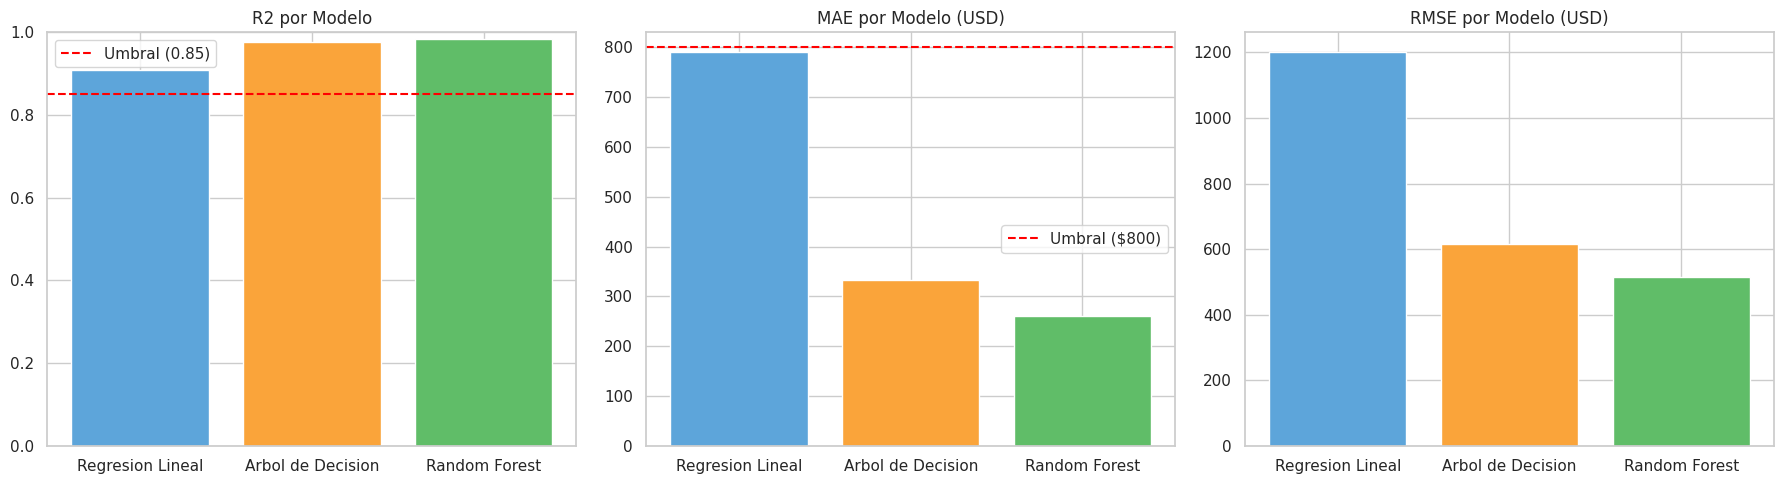

In [46]:
# Grafico comparativo de R2 por modelo
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

modelos = resultados.index.tolist()
colores = ["#5da5da", "#faa43a", "#60bd68"]

axes[0].bar(modelos, resultados["R2"], color=colores)
axes[0].set_title("R2 por Modelo")
axes[0].set_ylim(0, 1)
axes[0].axhline(y=0.85, color="red", linestyle="--", label="Umbral (0.85)")
axes[0].legend()

axes[1].bar(modelos, resultados["MAE"], color=colores)
axes[1].set_title("MAE por Modelo (USD)")
axes[1].axhline(y=800, color="red", linestyle="--", label="Umbral ($800)")
axes[1].legend()

axes[2].bar(modelos, resultados["RMSE"], color=colores)
axes[2].set_title("RMSE por Modelo (USD)")

plt.tight_layout()
plt.show()

In [47]:
# Identificar el mejor modelo segun R2
mejor = resultados["R2"].idxmax()
print(f"Mejor modelo: {mejor}")
print(f"  R2:   {resultados.loc[mejor, 'R2']:.4f}")
print(f"  MAE:  ${resultados.loc[mejor, 'MAE']:.2f}")
print(f"  RMSE: ${resultados.loc[mejor, 'RMSE']:.2f}")

# Verificar contra criterios de exito
r2_ok = resultados.loc[mejor, 'R2'] >= 0.85
mae_ok = resultados.loc[mejor, 'MAE'] < 800
print(f"\nCriterios de exito:")
print(f"  R2 >= 0.85: {'CUMPLE' if r2_ok else 'NO CUMPLE'}")
print(f"  MAE < $800: {'CUMPLE' if mae_ok else 'NO CUMPLE'}")

Mejor modelo: Random Forest
  R2:   0.9835
  MAE:  $261.31
  RMSE: $514.35

Criterios de exito:
  R2 >= 0.85: CUMPLE
  MAE < $800: CUMPLE


In [48]:
# Seleccionar predicciones del mejor modelo
predicciones = {"Regresion Lineal": y_pred_lr, "Arbol de Decision": y_pred_dt, "Random Forest": y_pred_rf}
y_pred_mejor = predicciones[mejor]

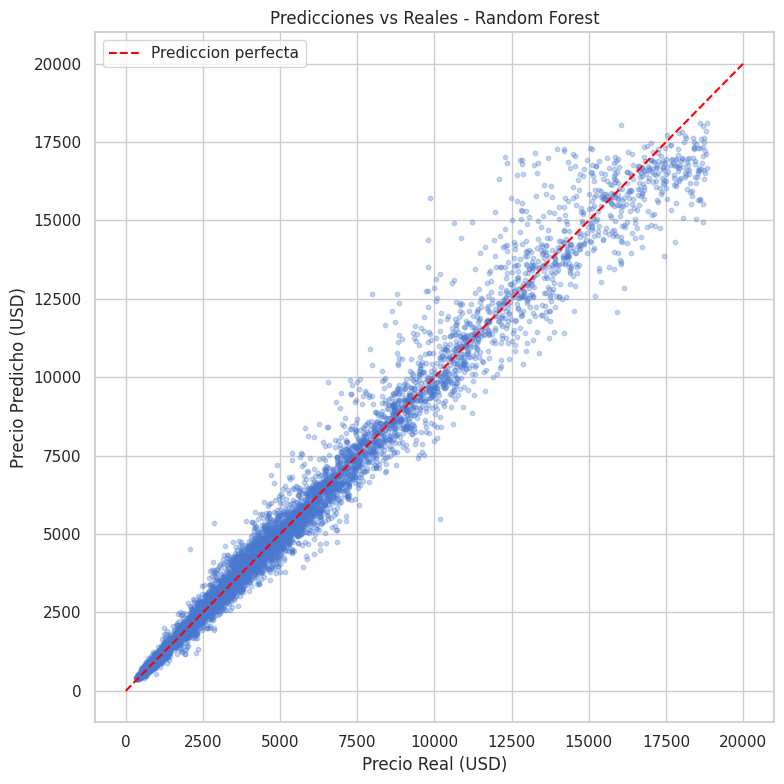

In [49]:
# Predicciones vs valores reales (mejor modelo)
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_mejor, alpha=0.3, s=10)
plt.plot([0, 20000], [0, 20000], color="red", linestyle="--", label="Prediccion perfecta")
plt.xlabel("Precio Real (USD)")
plt.ylabel("Precio Predicho (USD)")
plt.title(f"Predicciones vs Reales - {mejor}")
plt.legend()
plt.tight_layout()
plt.show()

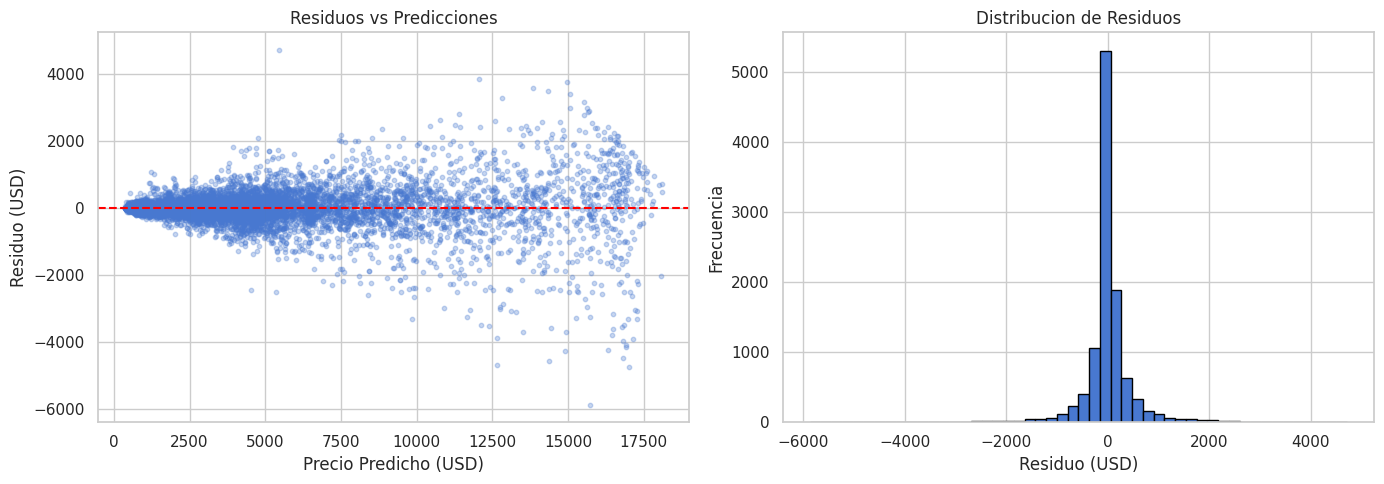

Residuo medio: $-2.76
Residuo std: $514.37


In [50]:
# Analisis de residuos (mejor modelo)
residuos = y_test - y_pred_mejor

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred_mejor, residuos, alpha=0.3, s=10)
axes[0].axhline(y=0, color="red", linestyle="--")
axes[0].set_xlabel("Precio Predicho (USD)")
axes[0].set_ylabel("Residuo (USD)")
axes[0].set_title("Residuos vs Predicciones")

axes[1].hist(residuos, bins=50, edgecolor="black")
axes[1].set_xlabel("Residuo (USD)")
axes[1].set_ylabel("Frecuencia")
axes[1].set_title("Distribucion de Residuos")

plt.tight_layout()
plt.show()

print(f"Residuo medio: ${residuos.mean():.2f}")
print(f"Residuo std: ${residuos.std():.2f}")

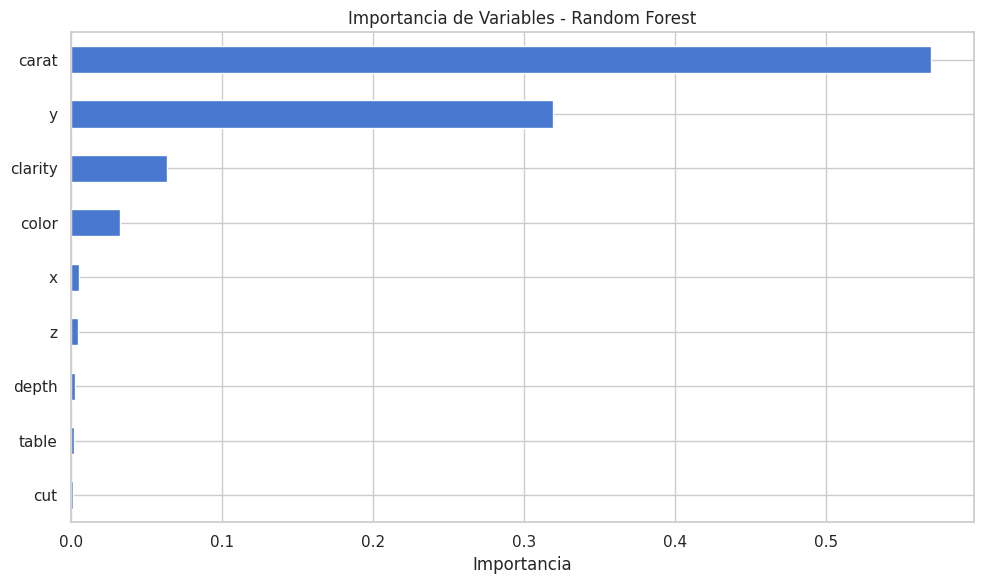

In [51]:
# Importancia de features (mejor modelo si es basado en arboles)
modelo_importancia = rf if mejor == "Random Forest" else dt
importancias = pd.Series(modelo_importancia.feature_importances_, index=X.columns)
importancias = importancias.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importancias.plot(kind="barh")
plt.title(f"Importancia de Variables - {mejor}")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

In [52]:
# Ejemplo de prediccion
ejemplo = X_test_scaled[0].reshape(1, -1)
precio_real = y_test.iloc[0]
precio_pred = modelo_importancia.predict(scaler.transform(X_test.iloc[[0]]))[0]

print(f"Precio real: ${precio_real:,.2f}")
print(f"Precio predicho: ${precio_pred:,.2f}")
print(f"Diferencia: ${abs(precio_real - precio_pred):,.2f}")

Precio real: $874.00
Precio predicho: $959.18
Diferencia: $85.18


In [53]:
# ANALISIS DE ETICA Y SESGOS

In [54]:
# Sesgo en la distribucion del precio
q1 = (y <= y.quantile(0.25)).sum()
q4 = (y > y.quantile(0.75)).sum()
print(f"{q1} ({q1/len(y)*100:.1f}%)")
print(f"{q4} ({q4/len(y)*100:.1f}%)")

13483 (25.0%)
13480 (25.0%)


Analisis de Etica y Sesgos

1. Sesgo en la distribucion del precio:
   Diamantes con precio bajo (Q1): 13483 (25.0%)
   Diamantes con precio alto (Q4): 13480 (25.0%)
   El modelo tiene mas datos de diamantes baratos,
   lo que puede generar predicciones menos precisas
   para diamantes de alto valor.

In [55]:
# Error del modelo por rango de precio
print("2. Error segun rango de precio:")
rangos = pd.cut(y_test, bins=[0, 1000, 5000, 10000, 20000],
                labels=["$0-1K", "$1K-5K", "$5K-10K", "$10K-20K"])
for rango in rangos.unique().dropna().sort_values():
    mask = rangos == rango
    mae_rango = mean_absolute_error(y_test[mask], y_pred_mejor[mask])
    n = mask.sum()
    print(f"   {rango}: MAE = ${mae_rango:.2f} (n={n})")
print(f"   El error es mayor en diamantes caros,")
print(f"   lo que podria perjudicar a vendedores de diamantes premium.")

2. Error segun rango de precio:
   $0-1K: MAE = $43.08 (n=2887)
   $1K-5K: MAE = $177.33 (n=4977)
   $5K-10K: MAE = $463.69 (n=1870)
   $10K-20K: MAE = $899.00 (n=1050)
   El error es mayor en diamantes caros,
   lo que podria perjudicar a vendedores de diamantes premium.


2.  El error es mayor en diamantes caros,
   lo que podria perjudicar a vendedores de diamantes premium.
3. Consideraciones eticas adicionales:
   - Los precios del dataset son en USD y reflejan un mercado
     especifico. No necesariamente aplican a otros mercados.
   - El modelo no considera factores externos como la demanda,
     la marca del vendedor o certificaciones adicionales.
   - Usar este modelo como unica fuente de tasacion podria
     desplazar a gemologos expertos sin reemplazar completamente
     su criterio profesional.
   - Se recomienda usar el modelo como herramienta de apoyo,
     no como reemplazo total de la evaluacion humana.

# 7. Deployment
## Reflexion sobre la experiencia CRISP-DM
La metodologia CRISP-DM permitio abordar el proyecto de forma
estructurada, asegurando que cada fase se completara antes de
avanzar a la siguiente. Los puntos clave fueron:

- La fase de Business Understanding definio objetivos claros
  y medibles antes de tocar los datos.
- El Data Understanding revelo hallazgos no evidentes como
  la variable de confusion entre corte y precio.
- La Data Preparation demostro que decisiones como el tipo
  de encoding impactan directamente en los resultados.
- Comparar multiples modelos confirmo que no existe un
  algoritmo universalmente mejor; depende del problema.

## Limitaciones del Modelo
1. El dataset no incluye informacion sobre certificacion
   (GIA, AGS), que influye significativamente en el precio.
2. Los precios son historicos y no reflejan fluctuaciones
   actuales del mercado de diamantes.
3. El modelo tiene mayor error en diamantes de precio alto
   debido al desbalance en la distribucion del precio.
4. No se consideran factores como la procedencia, tratamientos
   o fluorescencia del diamante.
5. La multicolinealidad entre x, y, z y carat podria afectar
   la interpretabilidad de modelos lineales.